In [18]:
'''
Names: Prashant Ram, Muhammad Hassan
Course: CSC 177
Assignment: 2 - Linear Regression
Professor: Jagannadha Chidella
Details: This project deals with preprocessing data from a .csv file to ready it for
        data modelling and then using linear regression to test the model.
'''

import pandas
import matplotlib.pyplot as matPlot
import seaborn
import numpy
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import linear_model
from sklearn.model_selection import train_test_split



In [19]:
'''
This block reads the data from a .csv file and makes columns for the data
'''
try:
    # import the data from the .csv file. "data" = dataframe. Our data is using ; as a separator and quotes to enclose
    # the data. The first row is the header row so we use the correct separator and quote character or else pandas treats these
    # data as a single column which we don't want.
    data = pandas.read_csv('loan_data.csv')

    #print the data attribute columns
    print(data.columns)
        
    # print the number of rows and columns
    print(f'We have {data.shape[0]} rows')
    print(f'We have {data.shape[1]} columns')

    # print the first 5 rows of the data
    print('\n', data.head())
        
except Exception as e:
    print("An error occured while trying to read from the CSV file", e)

Index(['Text', 'Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio',
       'Employment_Status', 'Approval'],
      dtype='object')
We have 24000 rows
We have 7 columns

                                                 Text  Income  Credit_Score  \
0  I need a loan to pay for an international vaca...   26556           581   
1  I want to make home improvements like installi...  197392           389   
2  I need a loan for home renovation, including a...   44561           523   
3  I need funds to buy new furniture and applianc...  190363           729   
4           I need a loan to start a small business.   61853           732   

   Loan_Amount  DTI_Ratio Employment_Status  Approval  
0         8314      79.26          employed  Rejected  
1       111604      22.14          employed  Rejected  
2        34118      45.44          employed  Rejected  
3       118757      10.22        unemployed  Rejected  
4        19210      44.13          employed  Approved  


In [20]:
'''
This block counts the number of missing values in each column
'''

#list to hold the columns with missing values
missingColumns = []

#our original number of rows with unclean data
original_rows = data.shape[0]

try:
    #loop through the columns and get the number of missing values
    for i in data.columns:
        #get the total of column of missing values
        total = data[i].isnull().sum()
        #display the column and the missing values number
        print(f"{i}: {total}")

        #add missing value columns to the list
        if total > 0:
            missingColumns.append(i)

    #finally display which columns had missing values
    if len(missingColumns) == 0:
        print("\nThere were no missing values in the data set.")
    else:
        #display the columns with missing values
        print(f"\nThese columns had missing data: {missingColumns}")
    
#catch any reading errors
except Exception as e:
    print("umm. An error occurred while trying to count the missing values..", e)

Text: 0
Income: 0
Credit_Score: 0
Loan_Amount: 0
DTI_Ratio: 0
Employment_Status: 0
Approval: 0

There were no missing values in the data set.


In [21]:
'''
This block drops all rows and columns with missing data
'''
# print the number of rows and columns
original_rows = data.shape[0]
original_columns = data.shape[1]
print(f'We have {original_rows} [original] rows and {original_columns} columns')
print('\nOriginal Data:', data.head())
    
#drops all rows with no data
data = data.dropna()

clean_rows = data.shape[0]
clean_columns = data.shape[1]
print(f'\nWe have {clean_rows} [Clean] rows and {clean_columns} columns')
print('\nCleaned data Data:', data.head())

print(f'\n\nWe had {original_rows - clean_rows} rows and {original_columns - clean_columns} columns of missing data')

We have 24000 [original] rows and 7 columns

Original Data:                                                 Text  Income  Credit_Score  \
0  I need a loan to pay for an international vaca...   26556           581   
1  I want to make home improvements like installi...  197392           389   
2  I need a loan for home renovation, including a...   44561           523   
3  I need funds to buy new furniture and applianc...  190363           729   
4           I need a loan to start a small business.   61853           732   

   Loan_Amount  DTI_Ratio Employment_Status  Approval  
0         8314      79.26          employed  Rejected  
1       111604      22.14          employed  Rejected  
2        34118      45.44          employed  Rejected  
3       118757      10.22        unemployed  Rejected  
4        19210      44.13          employed  Approved  

We have 24000 [Clean] rows and 7 columns

Cleaned data Data:                                                 Text  Income  Credit_Scor

In [22]:
'''This block checks for duplicate rows and drops the ones that are duplicates'''
total_duplicates = data.duplicated().sum()

if total_duplicates != 0:
    data = data.drop_duplicates(inkeep='first')
    print(f"\nThere were {total_duplicates} duplicate rows in the data set.")
else:
    print("\nThere were no duplicate rows in the data set.")



There were no duplicate rows in the data set.


In [23]:
'''
All the data columns are numerical so we do not need to do any conversion from categorical to numerical data. To verfiy, we will
print out the data types.
'''
print(data.dtypes)

Text                  object
Income                 int64
Credit_Score           int64
Loan_Amount            int64
DTI_Ratio            float64
Employment_Status     object
Approval              object
dtype: object


In [24]:
'''This codes will remove any outliers in the data using z-score method. Out threshold is 3.0. Any data point with a z-score greater than 3.0 will 
be removed.'''

columns = data.select_dtypes(include=['float64', 'int64']).columns
with_outliers = data

#run this 5 times because for some reason it's unable to remove all the outliers in 3 loops.
for i in range(0, 5):
    for col in columns:
        Q1 = with_outliers[col].quantile(0.25)    
        Q3 = with_outliers[col].quantile(0.75)     
        IQR = Q3 - Q1                         
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        with_outliers= with_outliers[(with_outliers[col] >= lower_bound) & (with_outliers[col] <= upper_bound)]
        data = with_outliers

print("Original dataset with outliers:", original_rows)
print("Cleaned dataset without outliers:", with_outliers.shape[0])
print("Number of rows with outliers removed:", original_rows - with_outliers.shape[0])


Original dataset with outliers: 24000
Cleaned dataset without outliers: 20624
Number of rows with outliers removed: 3376


In [25]:
'''This block converts all the categorical data to numerical data using one-hot encoding.'''

data['Employment_Status'] = data['Employment_Status'].replace({'employed': 1, 'unemployed': 0}).infer_objects(copy=False)
data['Approval'] = data['Approval'].replace({'Approved': 1, 'Rejected': 0}).infer_objects(copy=False)

C:\Users\Moe66\AppData\Local\Temp\ipykernel_23284\638651646.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Employment_Status'] = data['Employment_Status'].replace({'employed': 1, 'unemployed': 0}).infer_objects(copy=False)
C:\Users\Moe66\AppData\Local\Temp\ipykernel_23284\638651646.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Approval'] = data['Approval'].replace({'Approved': 1, 'Rejected': 0}).infer_objects(copy=False)


In [26]:
'''Save the cleaned dataset to a new csv file. This will be used for the linear regression model.'''
try:
    data.to_csv('cleaned_loan_data.csv', index=False)
    print("Cleaned data saved to current directory as file name = cleaned_loan_data.csv")
except Exception as e:
    print("An error occurred while trying to save the cleaned data to a CSV file", e)

Cleaned data saved to current directory as file name = cleaned_loan_data.csv


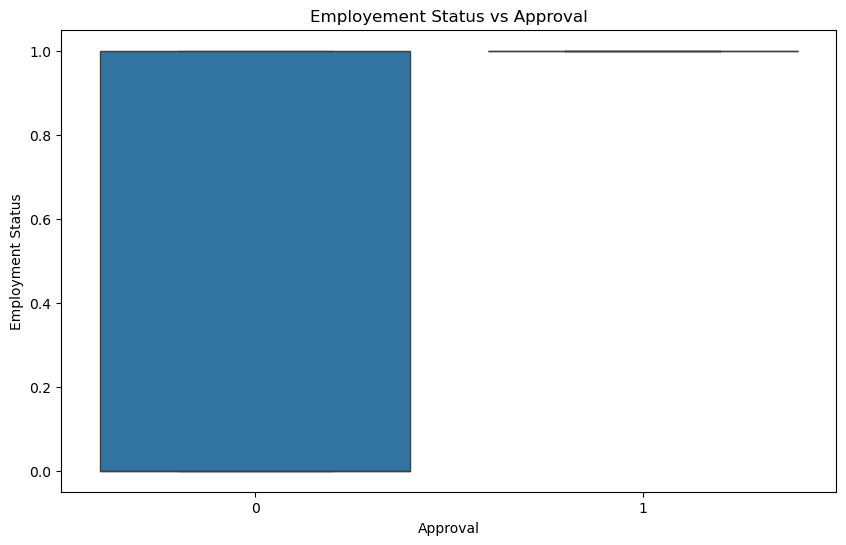

In [27]:
'''
This block plots the Sugar columns with the Quality column.
'''
#plot the data
matPlot.figure(figsize=(10, 6))
seaborn.boxplot(x='Approval', y='Employment_Status', data=data)
matPlot.title('Employement Status vs Approval')
matPlot.xlabel('Approval')
matPlot.ylabel('Employment Status')
matPlot.show()

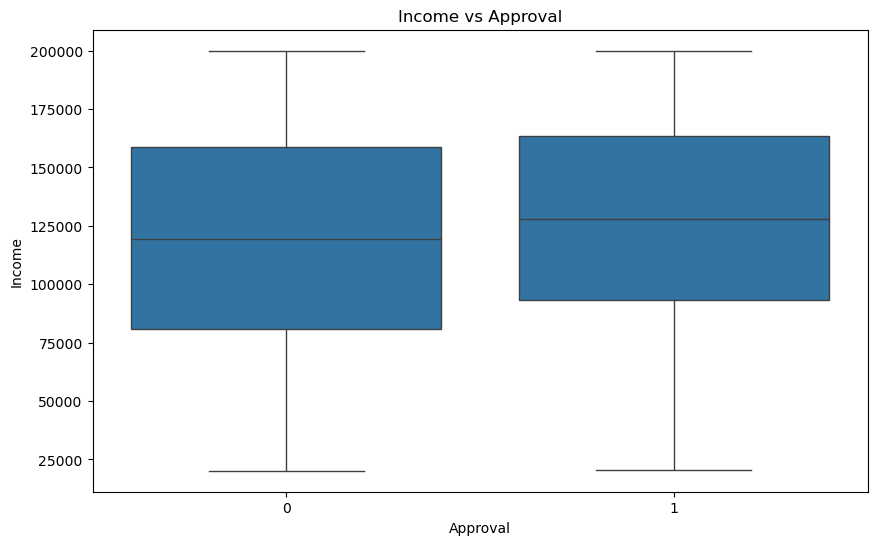

In [28]:
'''
This block plots the Sugar columns with the Quality column.
'''
#plot the data
matPlot.figure(figsize=(10, 6))
seaborn.boxplot(x='Approval', y='Income', data=data)
matPlot.title('Income vs Approval')
matPlot.xlabel('Approval')
matPlot.ylabel('Income')
matPlot.show()

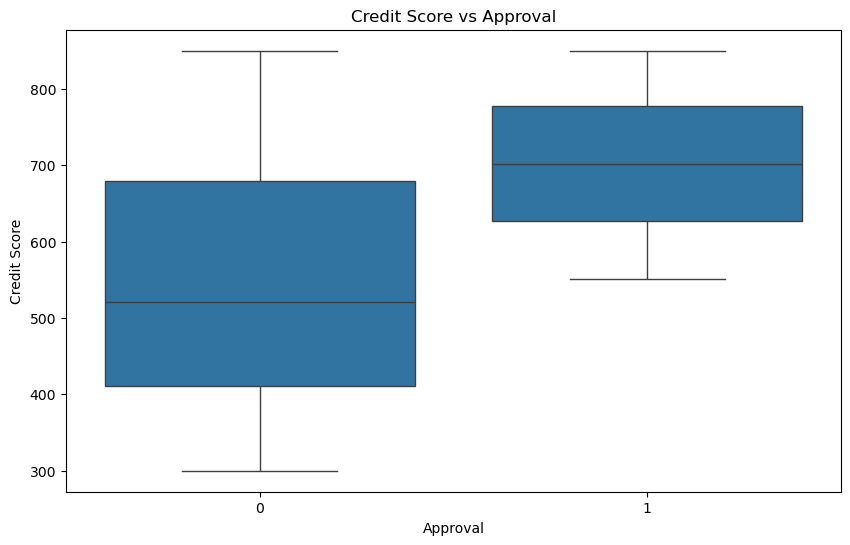

In [29]:
'''
This block plots the Sugar columns with the Quality column.
'''
#plot the data
matPlot.figure(figsize=(10, 6))
seaborn.boxplot(x='Approval', y='Credit_Score', data=data)
matPlot.title('Credit Score vs Approval')
matPlot.xlabel('Approval')
matPlot.ylabel('Credit Score')
matPlot.show()

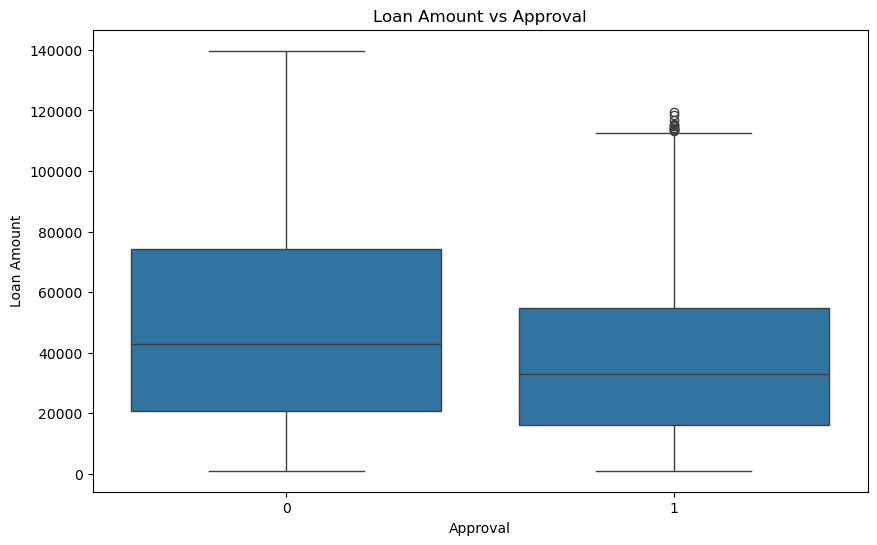

In [30]:
'''
This block plots the Sugar columns with the Quality column.
'''
#plot the data
matPlot.figure(figsize=(10, 6))
seaborn.boxplot(x='Approval', y='Loan_Amount', data=data)
matPlot.title('Loan Amount vs Approval')
matPlot.xlabel('Approval')
matPlot.ylabel('Loan Amount')
matPlot.show()

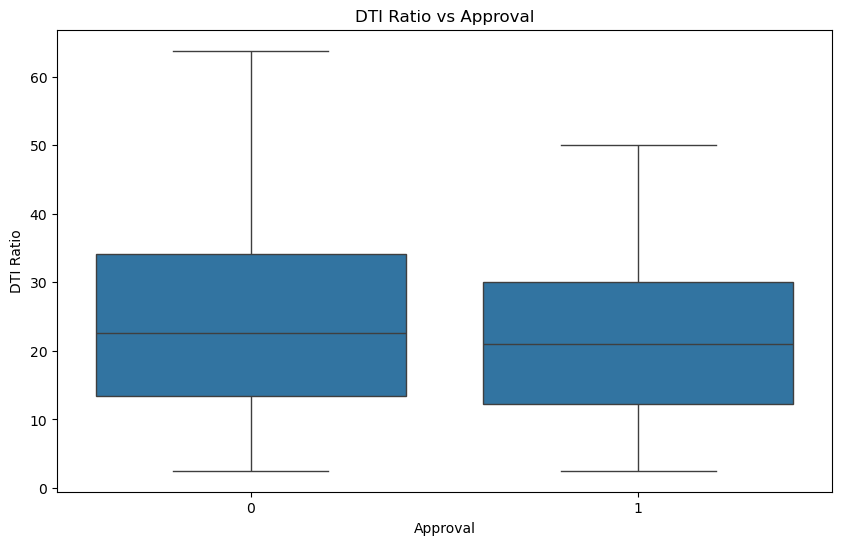

In [31]:
matPlot.figure(figsize=(10, 6))
seaborn.boxplot(x='Approval', y='DTI_Ratio', data=data)
matPlot.title('DTI Ratio vs Approval')
matPlot.xlabel('Approval')
matPlot.ylabel('DTI Ratio')
matPlot.show()

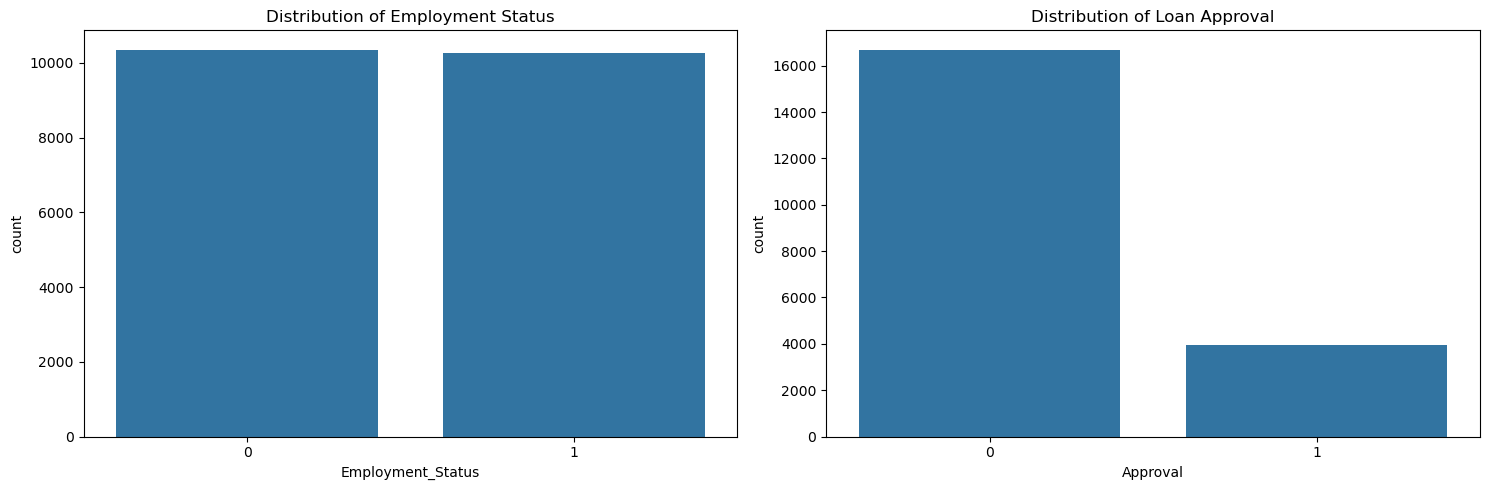

In [32]:
matPlot.figure(figsize=(15, 5))
matPlot.subplot(1, 2, 1)
seaborn.countplot(x='Employment_Status', data=data)
matPlot.title('Distribution of Employment Status')

matPlot.subplot(1, 2, 2)
seaborn.countplot(x='Approval', data=data)
matPlot.title('Distribution of Loan Approval')

matPlot.tight_layout()
matPlot.show()

In [33]:
'''This block balances the datase because currently, we have about 80% of it leaning towards 'rejected, i.e., 0' which heavily skews the data.'''

rejected = data[data["Approval"] == 0 ]
approved = data[data["Approval"] == 1]

# downsample the rejected results to match the approved class size
rejected_downsampled = rejected.sample(n=len(approved), random_state=42)

# combine the samples into 1 dataset
data = pandas.concat([rejected_downsampled, approved])

# print success
print("\nBalanced the dataset")


Balanced the dataset


In [34]:
'''
This block splits the cleaned dataset into training and testing data.
'''
from sklearn.model_selection import train_test_split

#display what should be the expected data modelling pre-split into training and testing data sets.
total_rows = data.shape[0]
training_data = int(0.8 * total_rows)
print(f'We have a total of {total_rows} rows of data.')
print(f'80% of {total_rows} is {training_data} which should be our testing data')
print(f'Training would be {total_rows - training_data}')

# the are our features and target variables (we exclude "Gender" column as it serves no purpose here)
features = data[['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio', 'Employment_Status']].values
target = data['Approval'].values

#splits the data 80 (training) and 20 (testing)
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=42, shuffle=True)

#showing the results of the split
print('\nRESULTS OF SPLIT')
print(f'Training set shape details are: x_train = {x_train.shape}, y_train= {y_train.shape}')
print(f'Testing set shape details are: x_test = {x_test.shape}, y_train= {y_test.shape}')

#Printing the data for the first 5 rows for both training and test datasets
print("\n--- Training Set Statistics ---")
print(x_train)  # Display the first 5 rows of the training set

print("\n--- Test Set Statistics ---")
print(x_test)  # Display the first 5 rows of the test set


We have a total of 7866 rows of data.
80% of 7866 is 6292 which should be our testing data
Training would be 1574

RESULTS OF SPLIT
Training set shape details are: x_train = (6292, 5), y_train= (6292,)
Testing set shape details are: x_test = (1574, 5), y_train= (1574,)

--- Training Set Statistics ---
[[1.80720e+05 8.49000e+02 1.32275e+05 5.75000e+00 0.00000e+00]
 [9.02230e+04 8.21000e+02 9.19000e+03 4.99900e+01 1.00000e+00]
 [6.46850e+04 5.86000e+02 2.57360e+04 4.31900e+01 1.00000e+00]
 ...
 [8.32850e+04 3.83000e+02 4.41650e+04 2.05900e+01 0.00000e+00]
 [1.64519e+05 5.99000e+02 4.57780e+04 2.73900e+01 1.00000e+00]
 [1.42938e+05 6.24000e+02 2.48300e+03 1.65500e+01 1.00000e+00]]

--- Test Set Statistics ---
[[6.70590e+04 6.27000e+02 2.28290e+04 1.68200e+01 1.00000e+00]
 [1.90067e+05 7.14000e+02 8.00440e+04 9.43000e+00 1.00000e+00]
 [1.44109e+05 5.18000e+02 8.47770e+04 1.88800e+01 1.00000e+00]
 ...
 [9.48470e+04 8.38000e+02 3.69950e+04 6.37000e+00 1.00000e+00]
 [1.53212e+05 5.30000e+02 3

In [35]:
# We calculate the meana nd stanard deviation for the training and test data to compare the model's results
train_mean = x_train.mean()
train_std = x_train.std()

test_mean = x_test.mean()
test_std = x_test.std()

# we display the mean and standard deviation to see if the results match.
print(f'The mean for the training data is {train_mean} and the standard deviation is {train_std}')
print(f'The mean for the testing data is {test_mean} and the standard deviation is {test_std}')

The mean for the training data is 33326.60257660521 and the standard deviation is 53705.25745370224
The mean for the testing data is 33482.555667090215 and the standard deviation is 53996.87421169361


In [36]:
# This is the start of assignment 2

In [37]:
# Part (a) - Regression

The Root Mean Square Error = 31771.7144
The R-squared = 0.0042


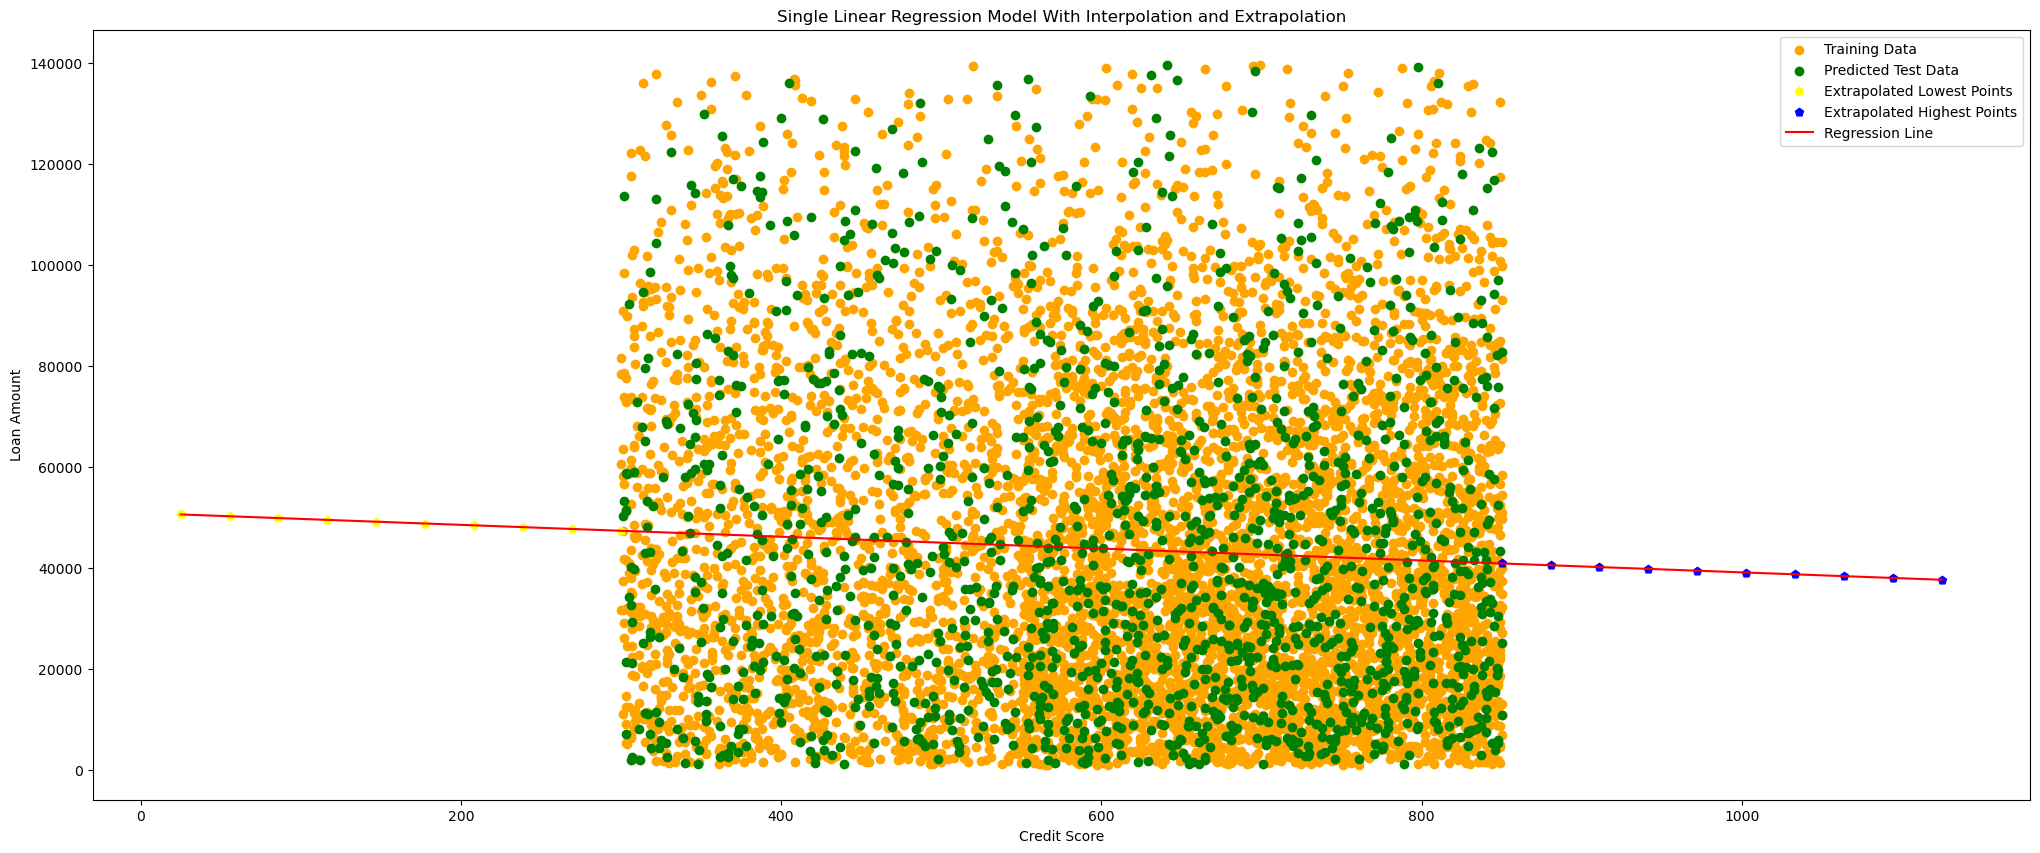

In [38]:
'''This block creates a linear regression model for 'Employment Status' feature against 'Approval' target'''

#create a linear regression model for 'Employment Status' vs 'Approval'
x = data['Credit_Score'].values.reshape(-1, 1)  
y = data['Loan_Amount'].values

#split the dataset into training and test sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

#create a single linear regression model object
single_regression = LinearRegression()

#fit the model to the training data
single_regression.fit(x_train, y_train)

#apply the model to the test data to get predictions
y_predicted_single = single_regression.predict(x_test)

#model evaluation using RMSE and R-squared
rmse = numpy.sqrt(mean_squared_error(y_test, y_predicted_single))
r_squared_score = r2_score(y_test, y_predicted_single)

print('The Root Mean Square Error = %.4f' % rmse)
print('The R-squared = %.4f' % r_squared_score)

#handle case for extrapolation: determine the training range
x_min = x_train.min()
x_max = x_train.max()

belowMin = numpy.linspace(x_min - (x_max - x_min) * 0.5, x_min, 10).reshape(-1, 1)
aboveMax = numpy.linspace(x_max, x_max + (x_max - x_min) * 0.5, 10).reshape(-1, 1)

#combine test data with extrapolation points
x_combined = numpy.vstack([x_test, belowMin, aboveMax])
y_combined_pred = single_regression.predict(x_combined)

#sort the combined x values and corresponding predictions for a smooth line
sorted_idx = numpy.argsort(x_combined.ravel())
x_combined_sorted = x_combined[sorted_idx]
y_combined_sorted = y_combined_pred[sorted_idx]

#plotting
matPlot.figure(figsize=(25, 10))

#plot training data
matPlot.scatter(x_train, y_train, color='orange', label='Training Data')

#plot test data (observed)
matPlot.scatter(x_test, y_test, color='green', label='Predicted Test Data', marker='o')

#plot extrapolation points
matPlot.scatter(belowMin, single_regression.predict(belowMin), color='yellow', label='Extrapolated Lowest Points', marker='p')
matPlot.scatter(aboveMax, single_regression.predict(aboveMax), color='blue', label='Extrapolated Highest Points', marker='p')

#plot the regression line as a continuous line
matPlot.plot(x_combined_sorted, y_combined_sorted, color='red', label='Regression Line')

matPlot.title('Single Linear Regression Model With Interpolation and Extrapolation')
matPlot.xlabel('Credit Score')
matPlot.ylabel('Loan Amount')
matPlot.legend()
matPlot.show()


The Root Mean Square Error = 31771.7144
The R-squared = 0.0042


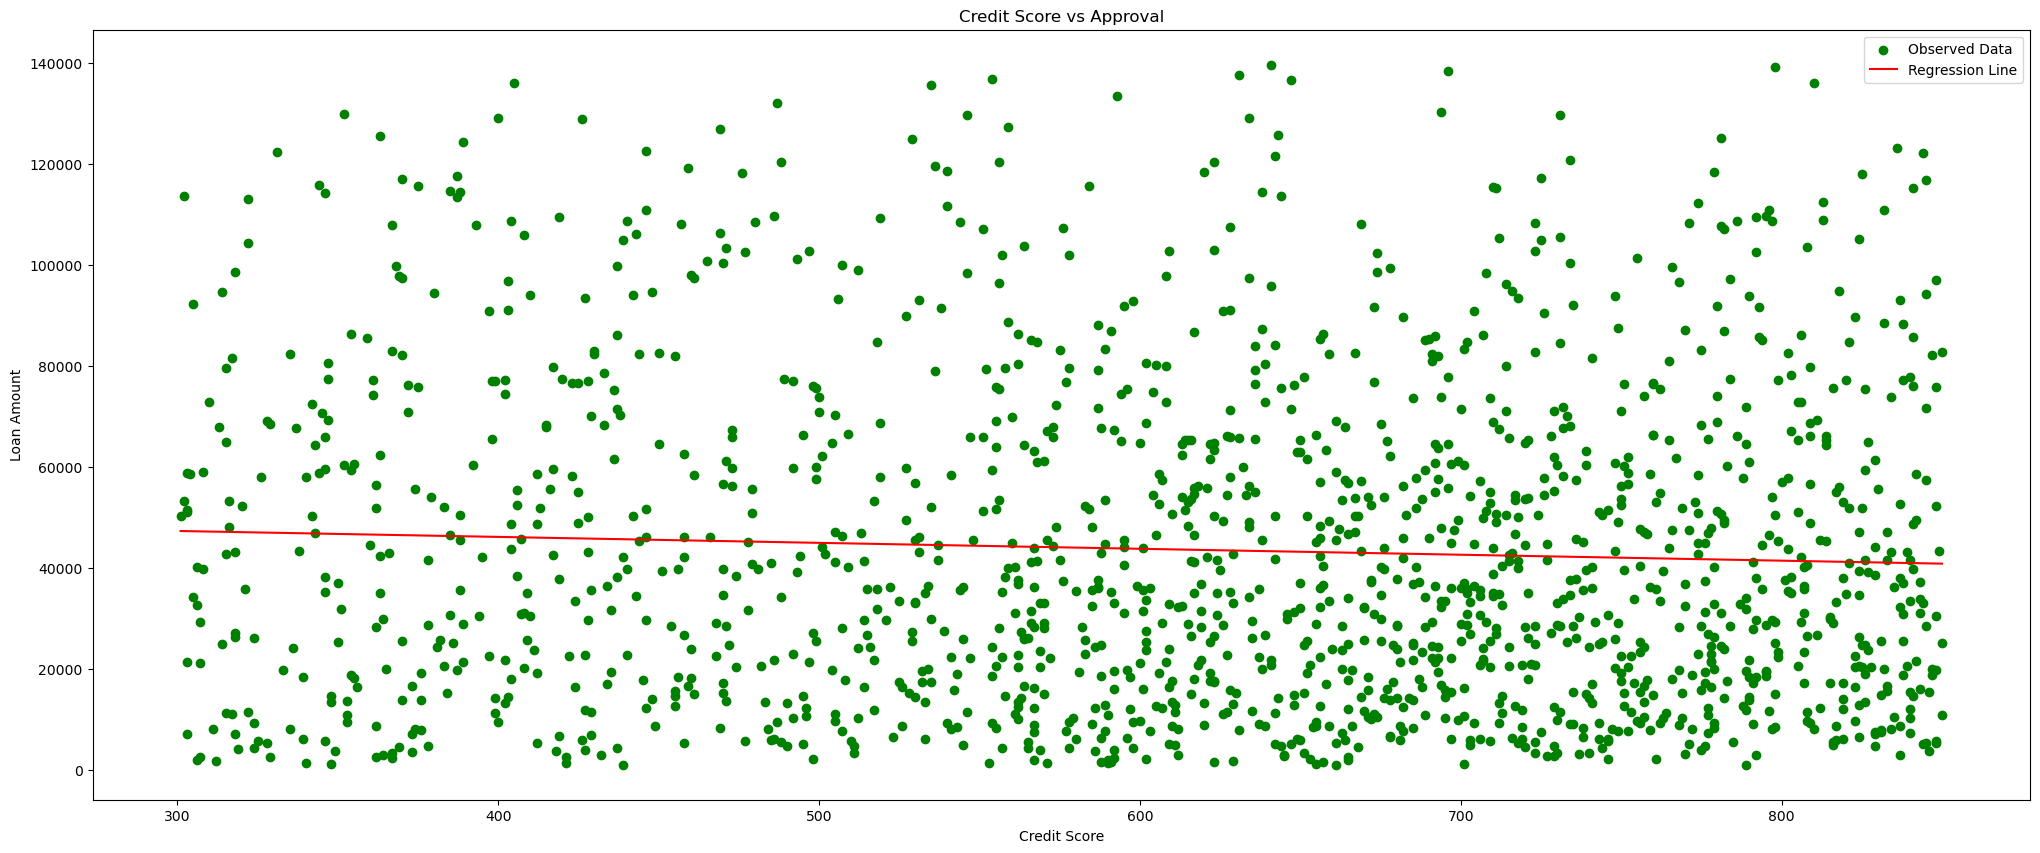

In [39]:
'''This block creates a single linear regression model for Credit Score feature against Approval target'''

'''This is only interpolation, no extrapolation'''

x = data['Credit_Score'].values.reshape(-1, 1)  
y = data['Loan_Amount'].values

#splitting the dataset into training and test sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

#create a single linear regression model object
single_regression = LinearRegression()

#fit the model to the training data
single_regression.fit(x_train, y_train)

#apply the model to the test data to get predictions
y_predicted_single = single_regression.predict(x_test)

#model evaluation using RMSE and R-squared
r = numpy.sqrt(mean_squared_error(y_test, y_predicted_single))
r_squared_score = r2_score(y_test, y_predicted_single)

print('The Root Mean Square Error = %.4f' % r)
print('The R-squared = %.4f' % r_squared_score)

#we need to sort x_test and the predicted values for a smooth regression line.
sorted_idx = numpy.argsort(x_test.ravel())
x_test_sorted = x_test[sorted_idx]
y_pred_sorted = y_predicted_single[sorted_idx]

#plot the test data as a scatter plot
matPlot.figure(figsize=(25, 10))
matPlot.scatter(x_test, y_test, color='green', label='Observed Data')
#plot the regression line
matPlot.plot(x_test_sorted, y_pred_sorted, color='red', label='Regression Line')
matPlot.title('Credit Score vs Approval')
matPlot.xlabel('Credit Score')
matPlot.ylabel('Loan Amount')
matPlot.legend()
matPlot.show()

The Root Mean Square Error = 0.3810
The R-squared = 0.4191


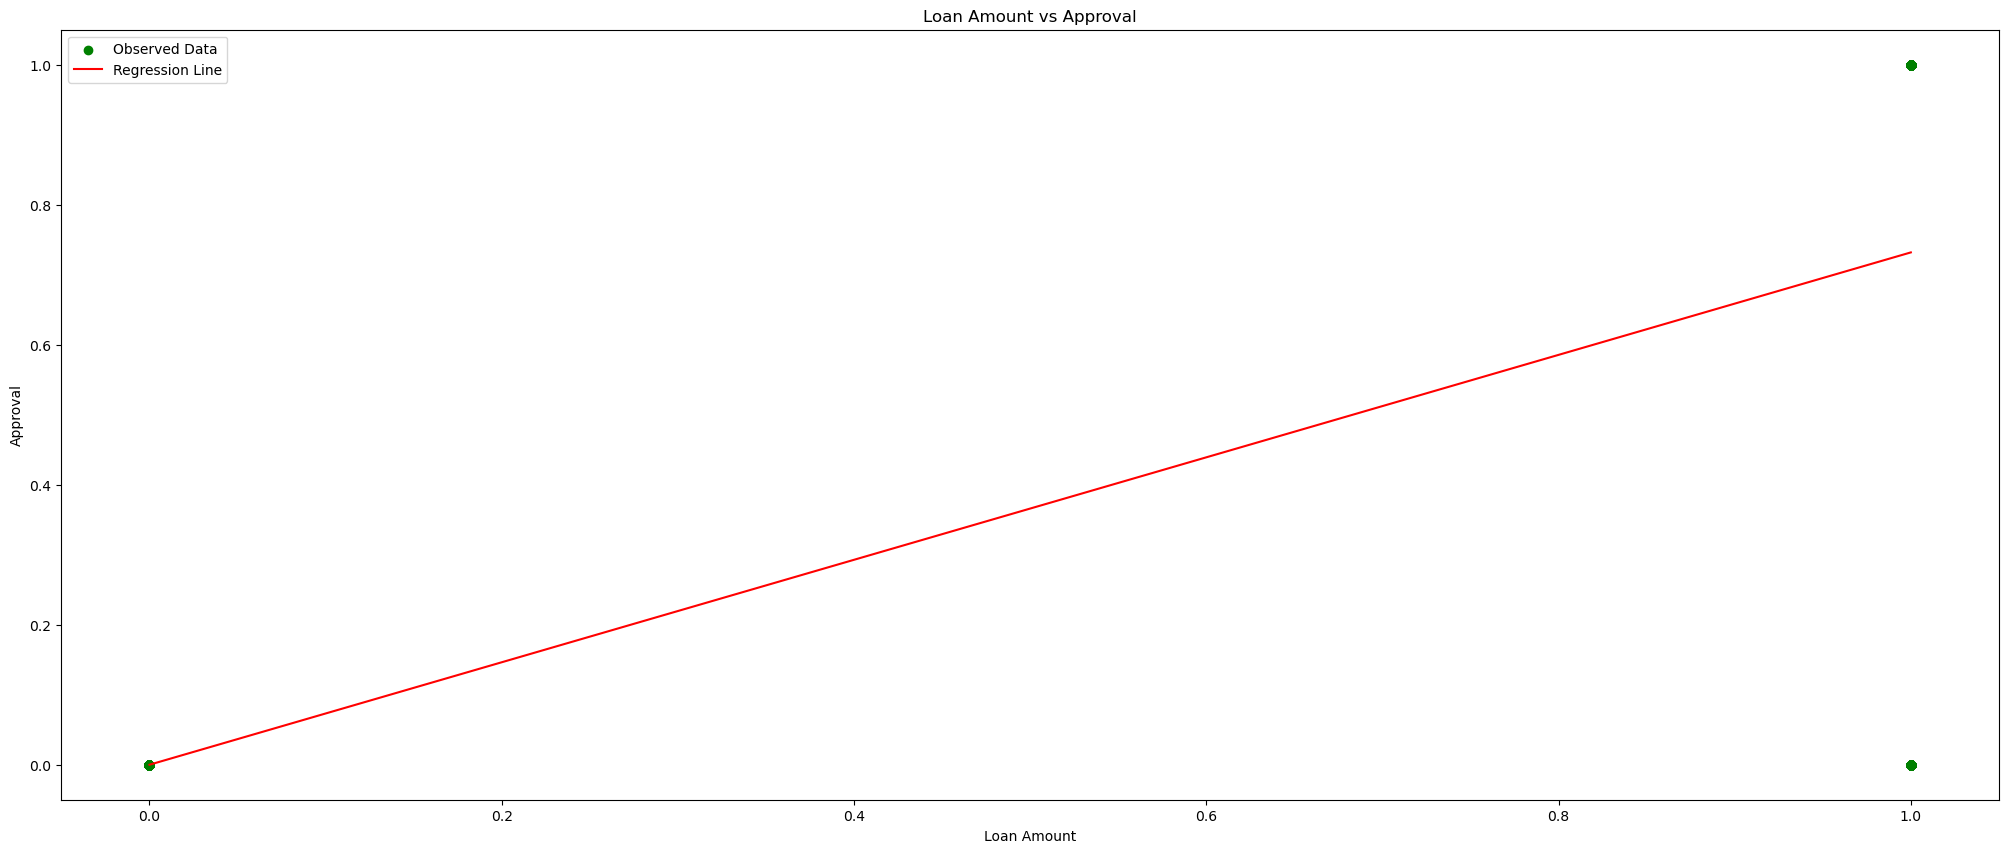

In [40]:
'''This block creates a linear regression model for Loan Amount feature against Approval target'''

'''Another interolated where both the feature and target are continuous variables'''

x = data['Employment_Status'].values.reshape(-1, 1)  
y = data['Approval'].values

#splitting the dataset into training and test sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

#create a single linear regression model object
single_regression = LinearRegression()

#fit the model to the training data
single_regression.fit(x_train, y_train)

#apply the model to the test data to get predictions
y_predicted_single = single_regression.predict(x_test)

#model evaluation using RMSE and R-squared
r = numpy.sqrt(mean_squared_error(y_test, y_predicted_single))
r_squared_score = r2_score(y_test, y_predicted_single)

print('The Root Mean Square Error = %.4f' % r)
print('The R-squared = %.4f' % r_squared_score)

#we need to sort x_test and the predicted values for a smooth regression line.
sorted_idx = numpy.argsort(x_test.ravel())
x_test_sorted = x_test[sorted_idx]
y_pred_sorted = y_predicted_single[sorted_idx]

#plot the test data as a scatter plot
matPlot.figure(figsize=(25, 10))
matPlot.scatter(x_test, y_test, color='green', label='Observed Data')
#plot the regression line
matPlot.plot(x_test_sorted, y_pred_sorted, color='red', label='Regression Line')
matPlot.title('Loan Amount vs Approval')
matPlot.xlabel('Loan Amount')
matPlot.ylabel('Approval')
matPlot.legend()
matPlot.show()

The Root Mean Square Error = 123.5643
The R-squared = 0.3204


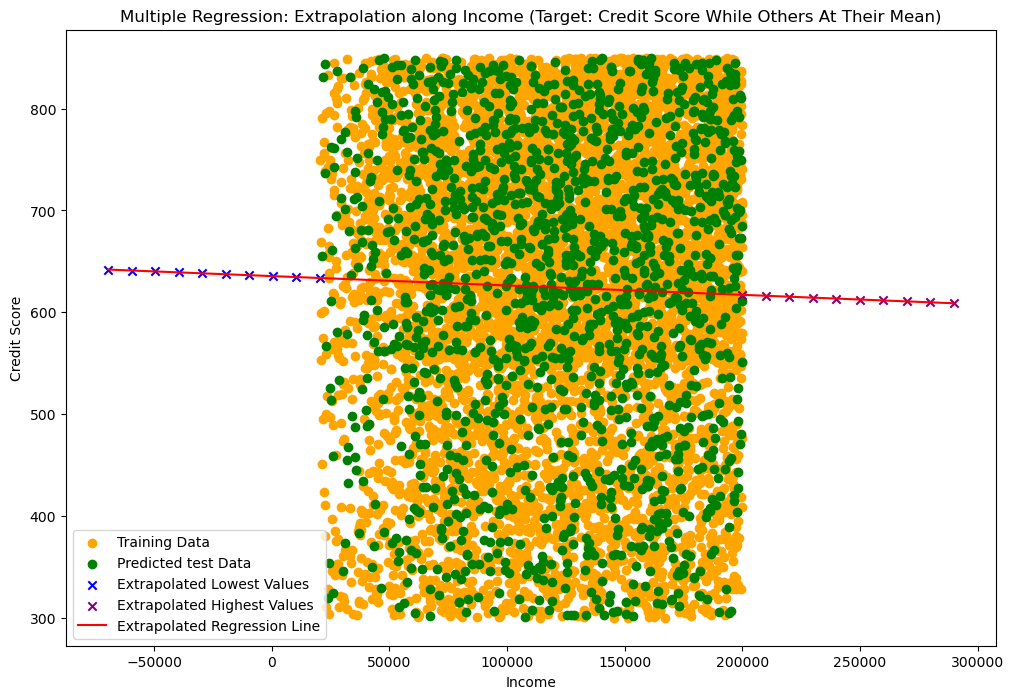

In [41]:
'''This block creates a multiple linear regression model for 'Credit Score' target with the 'Income' feature while keeping others at their mean values'''

#use four predictors for multiple regression and set Credit_Score as the target.
features = data[['Income', 'Loan_Amount', 'DTI_Ratio', 'Employment_Status', 'Approval']].values
target = data['Credit_Score'].values  # Now Credit_Score is the target

#split the dataset into training and test sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=42)

#create and fit the multiple regression model
multiple_regression = LinearRegression()
multiple_regression.fit(x_train, y_train)

#evaluate the model on the test set
y_predicted = multiple_regression.predict(x_test)
print('The Root Mean Square Error = %.4f' % numpy.sqrt(mean_squared_error(y_test, y_predicted)))
print('The R-squared = %.4f' % r2_score(y_test, y_predicted))

#extrapolation along Income (the first predictor, we'll vary Credit Score while holding other features at their mean values
mean_loan = numpy.mean(x_train[:, 1])
mean_DTI = numpy.mean(x_train[:, 2])
mean_employment = numpy.mean(x_train[:, 3])
mean_approval = numpy.mean(x_train[:, 4])

#determine the range for Income in the training data
income_min = x_train[:, 0].min()
income_max = x_train[:, 0].max()

#generate extra Income values for extrapolation:
income_extra_low = numpy.linspace(income_min - (income_max - income_min)*0.5, income_min, 10)
income_extra_high = numpy.linspace(income_max, income_max + (income_max - income_min)*0.5, 10)

#build full feature vectors for these extrapolated income values, keeping the other predictors constant:
X_extra_low = numpy.column_stack((
    income_extra_low,
    numpy.full(10, mean_loan),
    numpy.full(10, mean_DTI),
    numpy.full(10, mean_employment),
    numpy.full(10, mean_approval)
))
X_extra_high = numpy.column_stack((
    income_extra_high,
    numpy.full(10, mean_loan),
    numpy.full(10, mean_DTI),
    numpy.full(10, mean_employment),
    numpy.full(10, mean_approval)
))

#get predictions for these extrapolation points (predicted Credit_Score)
y_extra_low = multiple_regression.predict(X_extra_low)
y_extra_high = multiple_regression.predict(X_extra_high)

#combine the extrapolated income values and predictions for plotting the regression line smoothly:
income_combined = numpy.hstack([income_extra_low, income_extra_high])
y_combined_extrap = numpy.hstack([y_extra_low, y_extra_high])
sorted_idx = numpy.argsort(income_combined)
income_combined_sorted = income_combined[sorted_idx]
y_combined_sorted = y_combined_extrap[sorted_idx]

matPlot.figure(figsize=(12, 8))

# Plot training data (Income vs Credit_Score)
matPlot.scatter(x_train[:, 0], y_train, color='orange', label='Training Data')

# Plot test data (observed Income vs Credit_Score)
matPlot.scatter(x_test[:, 0], y_test, color='green', label='Predicted test Data')

# Plot extrapolated points:
matPlot.scatter(income_extra_low, y_extra_low, color='blue', marker='x', label='Extrapolated Lowest Values')
matPlot.scatter(income_extra_high, y_extra_high, color='purple', marker='x', label='Extrapolated Highest Values')

# Plot the regression line based on the extrapolated income values
matPlot.plot(income_combined_sorted, y_combined_sorted, color='red', label='Extrapolated Regression Line')

matPlot.title('Multiple Regression: Extrapolation along Income (Target: Credit Score While Others At Their Mean)')
matPlot.xlabel('Income')
matPlot.ylabel('Credit Score')
matPlot.legend()
matPlot.show()


The Root mean square error = 0.3133
The R-squared = 0.6074


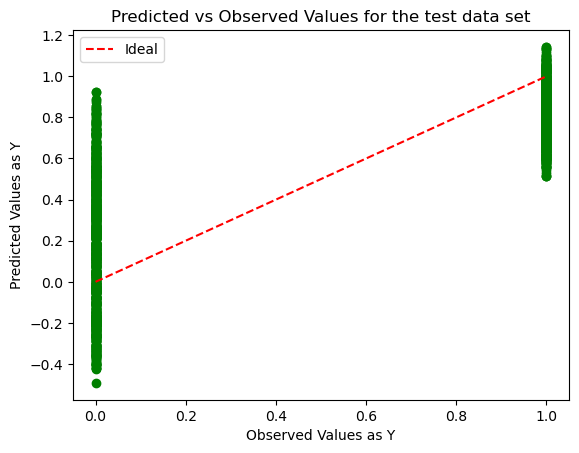

In [42]:

'''This block creates a multiple linear regression model for 'Approval' target with the other features'''

'''This is strictly interpolation, no extrapolation'''

features = data[['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio', 'Employment_Status']].values
target = data['Approval'].values

# Split the dataset into training and test sets
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=42)


# creating a multiple leaner model object
multiple_regression = linear_model.LinearRegression()

# fitting the model to the training data
multiple_regression.fit(x_train, y_train)

# applying the model to the test data
y_predicted = multiple_regression.predict(x_test)

# Evaluating the model
print('The Root mean square error = %.4f' % numpy.sqrt(mean_squared_error(y_test, y_predicted))) 
print('The R-squared = %.4f' % r2_score(y_test, y_predicted))

# comparing the predicted values with the observed values with a line of best-fit
matPlot.scatter(y_test, y_predicted, color='green')
matPlot.title('Predicted vs Observed Values for the test data set')
matPlot.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
matPlot.xlabel('Observed Values as Y')
matPlot.ylabel('Predicted Values as Y') 
matPlot.legend()
matPlot.show() 



In [103]:
# Part B: Combined Regression and Classification Analysis on Smaller Dataset

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# --- Load and Clean the Data ---
# Load the dataset
admissions_df = pd.read_csv("Admission_Predict_Ver1.1_small_data_set_for_Linear_Regression.csv")

# Clean column names by stripping any whitespace
admissions_df.columns = admissions_df.columns.str.strip()

# Drop the "Serial No." column if it exists
if "Serial No." in admissions_df.columns:
    df = admissions_df.drop(columns=["Serial No."])
else:
    df = admissions_df.copy()

# Display initial preview and column names
print("Initial dataset preview:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

# --- Data Exploration ---
# Print dataset info and summary statistics
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

Initial dataset preview:
   GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  Research  \
0        337          118                  4  4.5  4.5  9.65         1   
1        324          107                  4  4.0  4.5  8.87         1   
2        316          104                  3  3.0  3.5  8.00         1   
3        322          110                  3  3.5  2.5  8.67         1   
4        314          103                  2  2.0  3.0  8.21         0   

   Chance of Admit  
0             0.92  
1             0.76  
2             0.72  
3             0.80  
4             0.65  

Column names:
['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score       

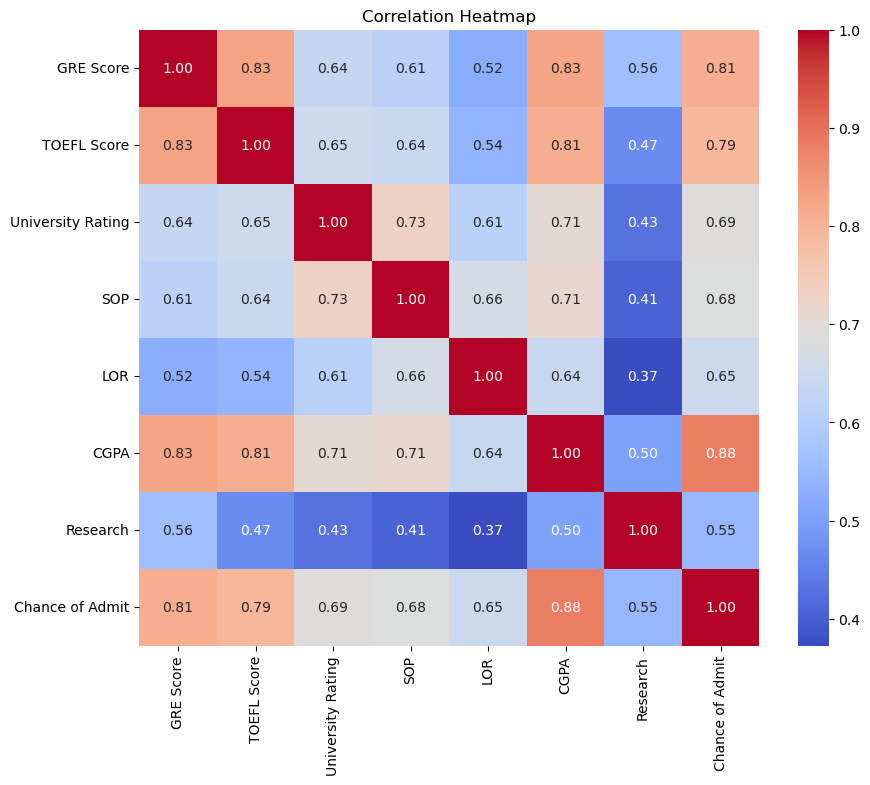

In [85]:
# Plot a correlation heatmap
plt.figure(figsize=(10,8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [107]:
# --- Define Features and Target for Regression ---
# For regression, the target is 'Chance of Admit'
if "Chance of Admit" not in df.columns:
    raise KeyError("Column 'Chance of Admit' not found in dataset.")
    
X = df.drop(columns=["Chance of Admit"])
y = df["Chance of Admit"]

# --- Train-Test Split (One Split for Both Analyses) ---
# Using a 80% train, 20% test split
X_train, X_test, y_train_cont, y_test_cont = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTrain-test split completed.")

# --- Feature Scaling for Regression (Multiple Linear Regression) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Regression Analysis ---
# (a) Simple Linear Regression using only 'GRE Score'
X_train_simple = X_train[["GRE Score"]]
X_test_simple = X_test[["GRE Score"]]

model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train_cont)
y_pred_simple = model_simple.predict(X_test_simple)


Train-test split completed.


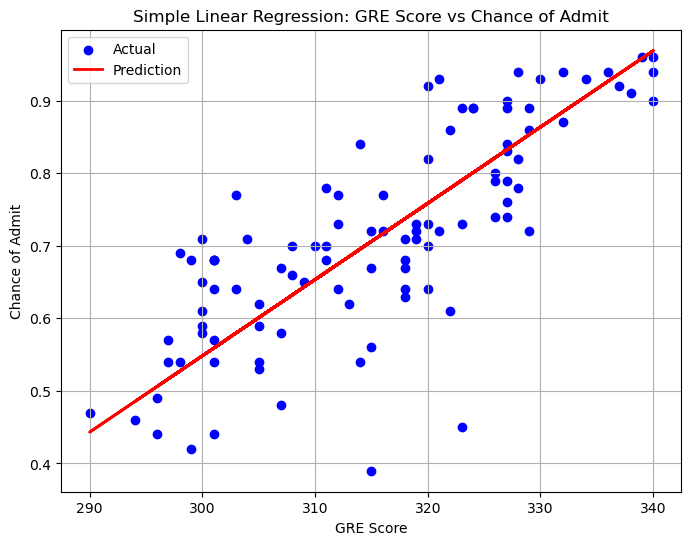

Simple Linear Regression Metrics:
MSE: 0.008464325543124892
R² Score: 0.5860965504584406

Multiple Linear Regression Metrics:
MSE: 0.0037046553987884114
R² Score: 0.8188432567829628


In [89]:
# Plot Simple Linear Regression
plt.figure(figsize=(8,6))
plt.scatter(X_test_simple, y_test_cont, color='blue', label='Actual')
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Prediction')
plt.title("Simple Linear Regression: GRE Score vs Chance of Admit")
plt.xlabel("GRE Score")
plt.ylabel("Chance of Admit")
plt.legend()
plt.grid(True)
plt.show()

print("Simple Linear Regression Metrics:")
print("MSE:", mean_squared_error(y_test_cont, y_pred_simple))
print("R² Score:", r2_score(y_test_cont, y_pred_simple))

# (b) Multiple Linear Regression using all features (scaled)
model_multi = LinearRegression()
model_multi.fit(X_train_scaled, y_train_cont)
y_pred_multi = model_multi.predict(X_test_scaled)

print("\nMultiple Linear Regression Metrics:")
print("MSE:", mean_squared_error(y_test_cont, y_pred_multi))
print("R² Score:", r2_score(y_test_cont, y_pred_multi))

C:\Users\Moe66\AppData\Local\Temp\ipykernel_23284\1831496069.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_class, palette='pastel')


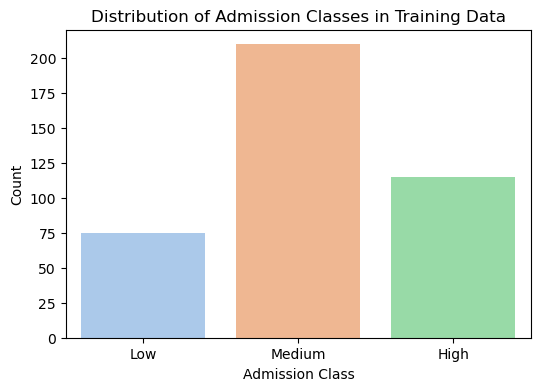

In [109]:
# --- Prepare Data for Classification ---
# Create classification target by binning the continuous target
# Define bins and labels (e.g., Low, Medium, High chance of admit)
bins = [0, 0.6, 0.8, 1.0]
labels = ["Low", "Medium", "High"]

# Apply binning on the train and test targets separately
y_train_class = pd.cut(y_train_cont, bins=bins, labels=labels)
y_test_class = pd.cut(y_test_cont, bins=bins, labels=labels)

# Optional: Display class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_class, palette='pastel')
plt.title("Distribution of Admission Classes in Training Data")
plt.xlabel("Admission Class")
plt.ylabel("Count")
plt.show()


Decision tree classifier trained successfully.


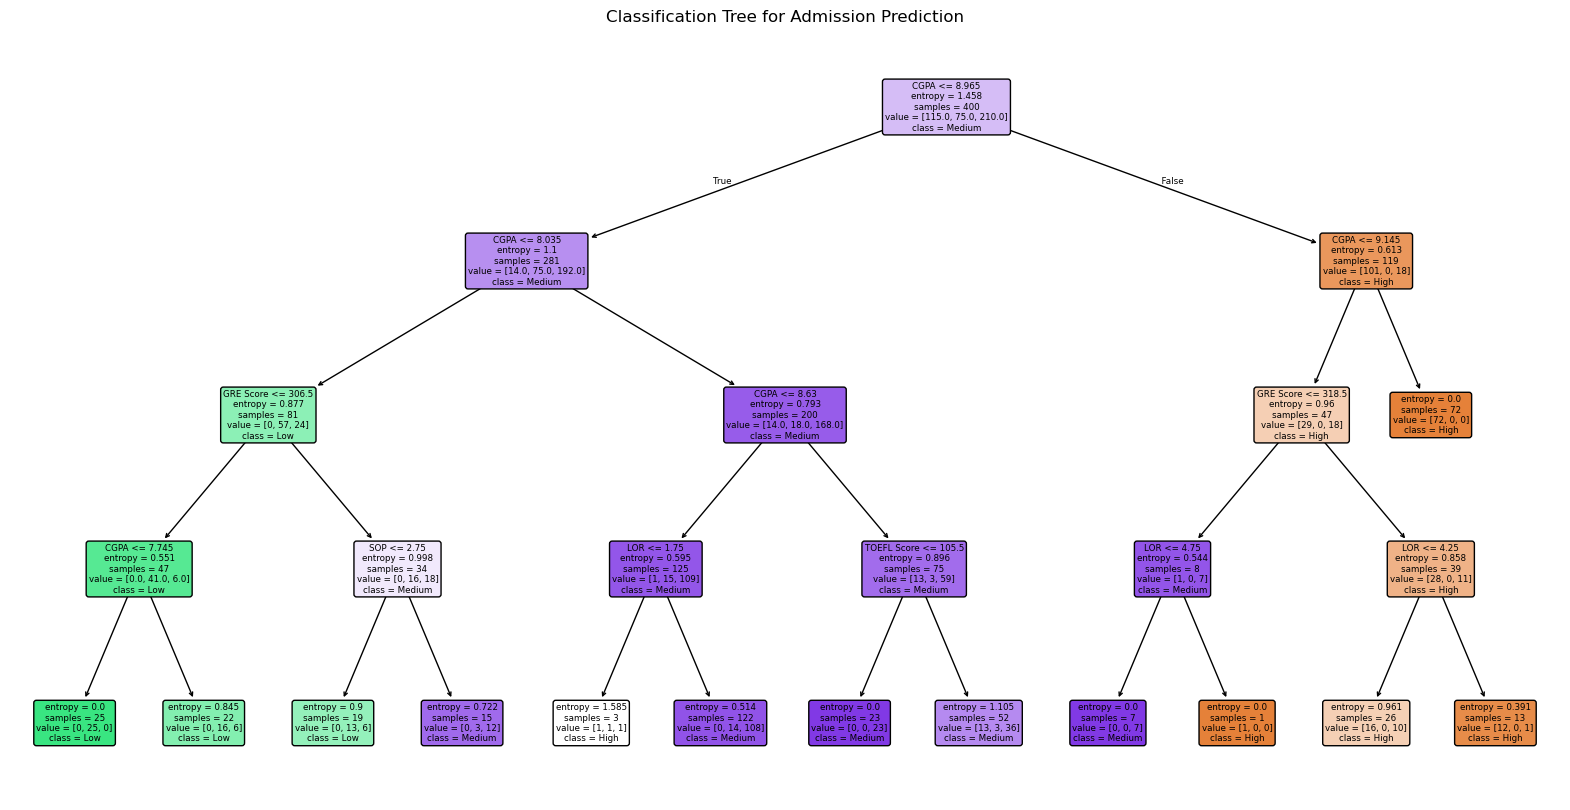

Classification Accuracy: 0.86


In [95]:
# --- Classification Tree ---
# Train a Decision Tree Classifier on the same features (no scaling needed for tree)
clf = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
clf.fit(X_train, y_train_class)
print("\nDecision tree classifier trained successfully.")

# Visualize the decision tree
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True, rounded=True)
plt.title("Classification Tree for Admission Prediction")
plt.show()

# Evaluate the classifier on the test set
accuracy = clf.score(X_test, y_test_class)
print("Classification Accuracy:", accuracy)


Extracted Decision Rules from the Classification Tree:
|--- CGPA <= 8.97
|   |--- CGPA <= 8.03
|   |   |--- GRE Score <= 306.50
|   |   |   |--- CGPA <= 7.75
|   |   |   |   |--- class: Low
|   |   |   |--- CGPA >  7.75
|   |   |   |   |--- class: Low
|   |   |--- GRE Score >  306.50
|   |   |   |--- SOP <= 2.75
|   |   |   |   |--- class: Low
|   |   |   |--- SOP >  2.75
|   |   |   |   |--- class: Medium
|   |--- CGPA >  8.03
|   |   |--- CGPA <= 8.63
|   |   |   |--- LOR <= 1.75
|   |   |   |   |--- class: High
|   |   |   |--- LOR >  1.75
|   |   |   |   |--- class: Medium
|   |   |--- CGPA >  8.63
|   |   |   |--- TOEFL Score <= 105.50
|   |   |   |   |--- class: Medium
|   |   |   |--- TOEFL Score >  105.50
|   |   |   |   |--- class: Medium
|--- CGPA >  8.97
|   |--- CGPA <= 9.14
|   |   |--- GRE Score <= 318.50
|   |   |   |--- LOR <= 4.75
|   |   |   |   |--- class: Medium
|   |   |   |--- LOR >  4.75
|   |   |   |   |--- class: High
|   |   |--- GRE Score >  318.50
|   |   |

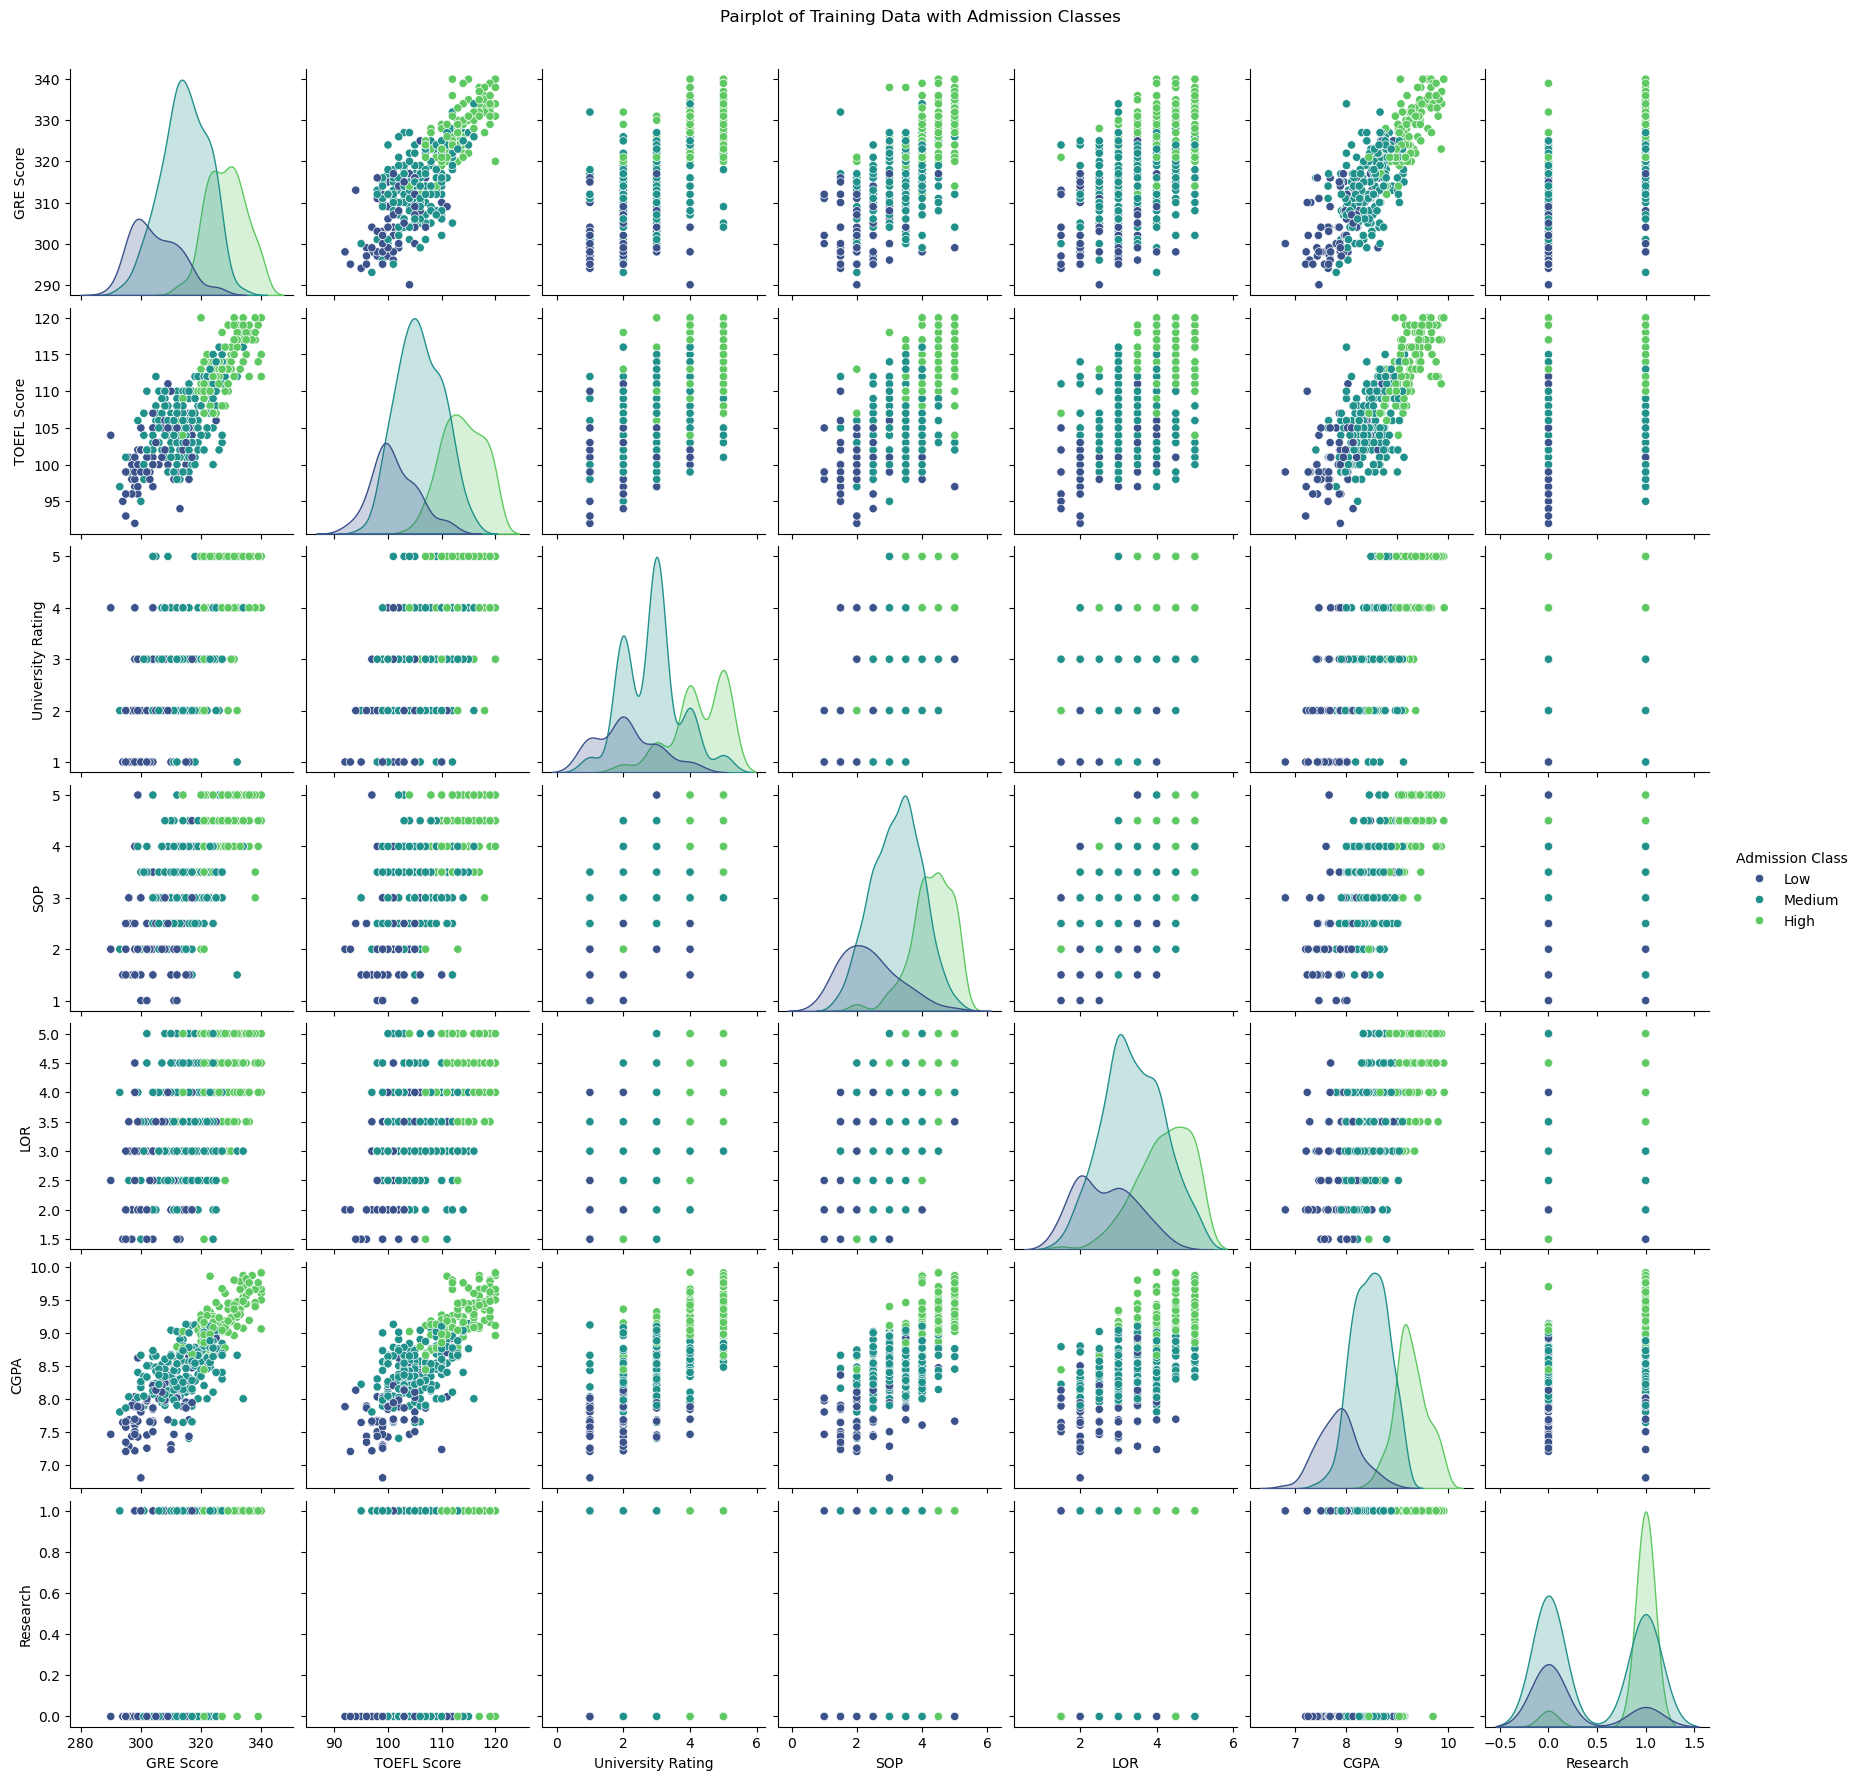

In [111]:
# --- Extract and Print Decision Rules ---
rules = export_text(clf, feature_names=list(X.columns))
print("\nExtracted Decision Rules from the Classification Tree:")
print(rules)

# --- Additional Visualization: Pairplot of Training Data with Classification Target ---
# Combine X_train and the classification target for visualization
train_data_for_pair = X_train.copy()
train_data_for_pair['Admission Class'] = y_train_class.values
sns.pairplot(train_data_for_pair, hue='Admission Class', palette='viridis')
plt.suptitle("Pairplot of Training Data with Admission Classes", y=1.02)
plt.show()

# End of Part B Code
